We want to solve $$ \mathrm{d} Y_t^m = \mu(Y_t^m,t) + \varsigma(Y_t^m,t) \mathrm{d} X_t^{m,-} + \sigma(Y_t^m,t) \mathrm{d} W_t^m$$ where 
- $W$ is a $d$-dimensional Brownian motion, $X$ is 1-dimensional $H$-fBm, possibly correlated with $W$; $Y$ is $n$-dimensional
- The ${}^m$ denotes piecewise-linear approximations and the ${}^-$ means lagged w.r.t. $W$ by one interval
- $\mu$ and $\varsigma$ take values in $\mathbb R^n$, $\sigma$ takes values in $\mathbb R^{n \times d}$

We begin by focusing on the case of $H = 1/2$ and $\mathrm{d}[X,W^k]_t = \rho^k \mathrm{d}t$ for some $\rho^k \in [-1,1]$. The equation then becomes $$ \mathrm{d}Y_t = \Big( \mu(Y_t,t) + \frac{\rho^k}{2}[\sigma_k,\varsigma](Y_t,t) \Big)\mathrm{d}t + \varsigma(Y_t,t) \circ \mathrm{d}X_t^- + \sigma(Y_t,t) \circ \mathrm{d}W_t $$ where $[\sigma_k,\varsigma]$ denotes the Lie bracket $\mathrm{D}\varsigma \sigma_k - \mathrm{D}\sigma_k \varsigma$. Let's take $d = 3$ and $\rho^k = \delta^{1k}$.

In [9]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree

In [142]:
# Global parameters, create brownian path(s)
t0, t1 = 0, 10
epsilon = 1e-2
times = jnp.arange(t0, t1, epsilon)
vbt = VirtualBrownianTree(t0, t1, tol=epsilon, shape=(1,), key=jr.PRNGKey(0))
bm_control = vbt.evaluate

bm_control(1)

# Note that here I am only retaining the method evaluate from VirtualBrownianTree. This is because it's the only one
# being used later on. But on should make sure nothing is being thrown out. From now on a "control" will be a
# a function that returns the increment: (s,t) |-> X_t - X_s.

Array([1.0214049], dtype=float32)

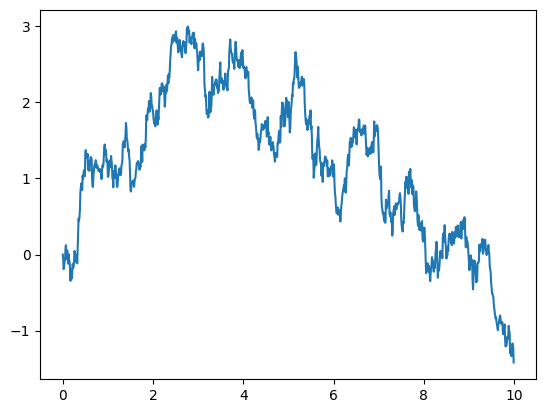

In [97]:
# Transform control (like brownian_motion, or more generally any function) to array, so that it can be plotted
def fun_to_array(grid, fun):
    return jax.vmap(lambda t: fun(t))(grid)
bm_array = fun_to_array(times, bm_control)
plt.plot(times,bm_array)
plt.show()

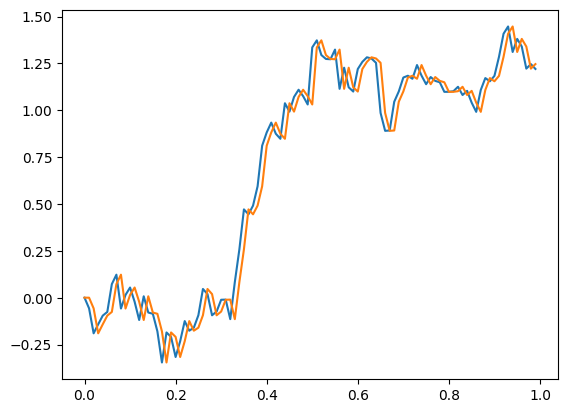

In [119]:
# Create lagged control from a given control and join them
def lagged_control(fun, lag):
    return lambda s,t: fun(jnp.maximum(0,t - lag)) - fun(jnp.maximum(0,s - lag))
lagged_bm_control = lagged_control(bm_control, epsilon)

def join_controls(lagged, original):
    return lambda s,t: jnp.concatenate((lagged(s,t), original(s,t)))

lead_lag_control = join_controls(bm_control, lagged_bm_control)

# Plot them side by side on a small interval
s0, s1 = 0, 100
lead_lag_array = fun_to_array(times, lambda t: lead_lag_control(0,t))
plt.plot(times[s0:s1],lead_lag_array[s0:s1])
plt.show()

In [14]:
# Do a simple example 1-dimensional ODE
# Solver with symbolic coefficients for n-dimensional

Let's start with $X$ and $W$ equal and 1-dimensional. $ \mathrm{d} Y_t^m = \varsigma(Y_t^m) \mathrm{d} X_t^{m,-} + \sigma(Y_t^m) \mathrm{d} W_t^m$ converges to $$ \mathrm{d}Y_t = (\sigma(Y_t) + \varsigma(Y_t)) \circ \mathrm{d}W_t + \frac{1}{2}[\sigma_k,\varsigma](Y_t,t) \mathrm{d}t. $$ Let's compare the solution to the approximating CDE with that to $\mathrm{d}Y_t = (\sigma(Y_t) + \varsigma(Y_t)) \circ \mathrm{d}W_t^m + \frac{1}{2}[\sigma_k,\varsigma](Y_t,t) \mathrm{d}t$.



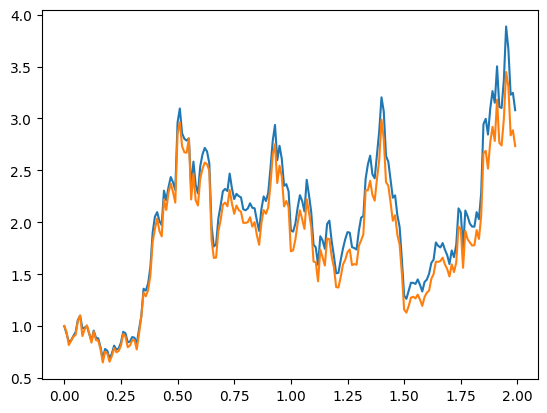

In [145]:
# First let's compare some of the solvers

diffusion = lambda t, y, args: jnp.array([y])
terms = ControlTerm(diffusion, bm_control)
solver = Euler()
saveat = SaveAt(dense=True)

# Euler, with finer grid than was used to generate the brownian motion
sol_euler_finer = diffeqsolve(terms, solver, t0, t1, dt0 = epsilon*0.6, y0=1.0, saveat=saveat)
euler_finer_array = fun_to_array(times, sol_euler_finer.evaluate)

# Euler, with the same grid as was used to generate the brownian motion
sol_euler_same = diffeqsolve(terms, solver, t0, t1, dt0 = epsilon, y0=1.0, saveat=saveat) #
euler_same_array = fun_to_array(times, sol_euler_same.evaluate)

s0, s1 = 0, 200
plt.plot(times[s0:s1], euler_finer_array[s0:s1])
plt.plot(times[s0:s1], euler_same_array[s0:s1])
plt.show()


In [41]:
# The solution to the CDE driven by the lead-lag control:

diffusion = lambda t, y, args: jnp.array([y, 0])
terms = ControlTerm(diffusion, lead_lag_control)
solver = Euler()
saveat = SaveAt(dense=True)